<a href="https://colab.research.google.com/github/pelatmn/BootcampYZTA_grup_112/blob/main/notebooks/talep_agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WasteZero AI — Talep Agent'ı

**Takım:** The Parsimonia · **Sorumlu:** Beyza ATA (Product Owner)

## Görev (DATA_SOURCES.md'den)
> **Talep Agent'ı — Görev:** Kategori bazlı satış/talep tahmini.
> **Veri seti:** Food Demand Dataset (Genpact)

Mimari kuralı: *"Agent'lar tahmin ve profillerini ürün kategorisi düzeyinde üretir; orkestratör bu kategori profillerini karar anında birleştirir."*

## Yaklaşım
1. Genpact verisi (`meal_id` kodlu) + `meal_info.csv` birleştirilir → her yemeğin kategorisi bulunur.
2. Genpact'in 14 kategorisi, projenin **5 ortak kategorisine** eşlenir: `corba, ana_yemek, salata, tatli, icecek`.
3. Model **satır seviyesinde** (hafta × merkez × yemek) eğitilir — burada fiyat/promosyon/geçmiş sinyali vardır.
4. Tahminler **kategoriye toplanır** → agent'ın orkestratöre verdiği çıktı budur.

> **Neden satır seviyesinde eğitiyoruz?** Doğrudan kategori seviyesinde eğitmeyi denedik: sadece ~693 satır kalıyor ve model, "geçen hafta ne sattıysa o" naif tahminini **yenemiyor** (%15.9 vs %12.4 MAPE). Satır seviyesinde eğitip toplayınca MAPE **%8.27**'ye düşüyor. Doküman çıktının kategori düzeyinde olmasını ister, eğitim seviyesini şart koşmaz.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110

## 1. Veriyi yükle

Veriler doğrudan takım reposundan çekilir (indirmeye gerek yok).

In [2]:
REPO = "https://raw.githubusercontent.com/pelatmn/BootcampYZTA_grup_112/main"

train = pd.read_csv(f"{REPO}/data/raw/Food%20Demand%20Forecasting.csv")

# meal_info.csv repoya henüz push edilmediyse aynadan çek (yedek)
try:
    meal = pd.read_csv(f"{REPO}/data/raw/meal_info.csv")
    print("meal_info: repodan yüklendi")
except Exception:
    meal = pd.read_csv("https://raw.githubusercontent.com/Erdos1729/food-demand-forecasting/master/datasets/meal_info.csv")
    print("meal_info: aynadan yüklendi (repoya eklemeyi unutma!)")

print("train:", train.shape, "| meal_info:", meal.shape)
train.head()

meal_info: aynadan yüklendi (repoya eklemeyi unutma!)
train: (456548, 9) | meal_info: (51, 3)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


## 2. Kategori eşlemesi

Genpact'in kendi kategorileri (14 adet) projenin **5 ortak kategorisine** eşlenir.
`Soup→corba`, `Salad→salata`, `Desert→tatli`, `Beverages→icecek`, **kalan her şey** → `ana_yemek`.

In [3]:
CAT_MAP = {"Soup": "corba", "Salad": "salata", "Desert": "tatli", "Beverages": "icecek"}

df = train.merge(meal, on="meal_id", how="left")
df["category_tr"] = df["category"].map(CAT_MAP).fillna("ana_yemek")

print("Genpact kategorisi -> ortak kategori:")
print(df.groupby("category")["category_tr"].first().to_string())
print()
print(df["category_tr"].value_counts())

Genpact kategorisi -> ortak kategori:
category
Beverages          icecek
Biryani         ana_yemek
Desert              tatli
Extras          ana_yemek
Fish            ana_yemek
Other Snacks    ana_yemek
Pasta           ana_yemek
Pizza           ana_yemek
Rice Bowl       ana_yemek
Salad              salata
Sandwich        ana_yemek
Seafood         ana_yemek
Soup                corba
Starters        ana_yemek

category_tr
ana_yemek    258130
icecek       127890
tatli         29294
salata        28559
corba         12675
Name: count, dtype: int64


## 3. Keşifsel analiz (EDA)

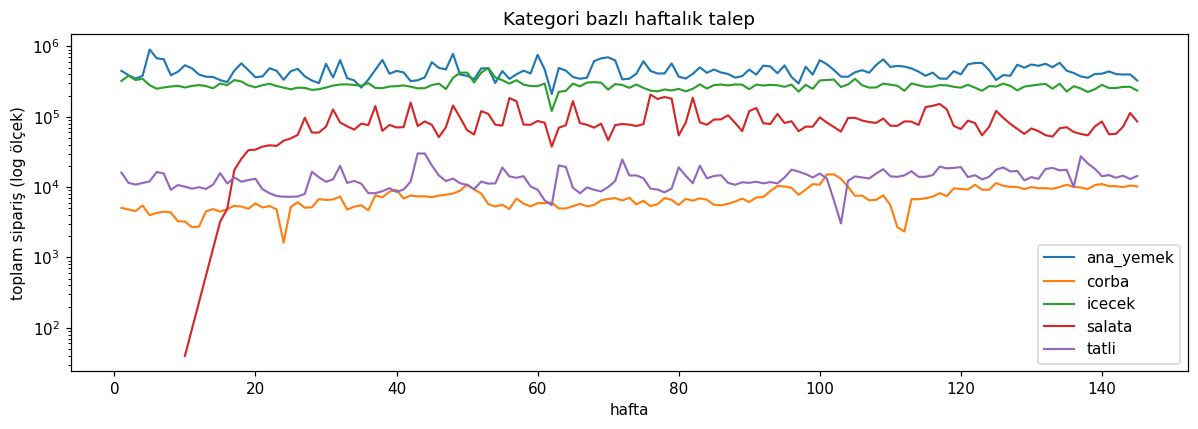

In [4]:
weekly = df.groupby(["week", "category_tr"], as_index=False).num_orders.sum()

fig, ax = plt.subplots(figsize=(11, 4))
for c, sub in weekly.groupby("category_tr"):
    ax.plot(sub.week, sub.num_orders, label=c, linewidth=1.4)
ax.set_yscale("log")
ax.set_xlabel("hafta"); ax.set_ylabel("toplam sipariş (log ölçek)")
ax.set_title("Kategori bazlı haftalık talep")
ax.legend(); plt.tight_layout(); plt.show()

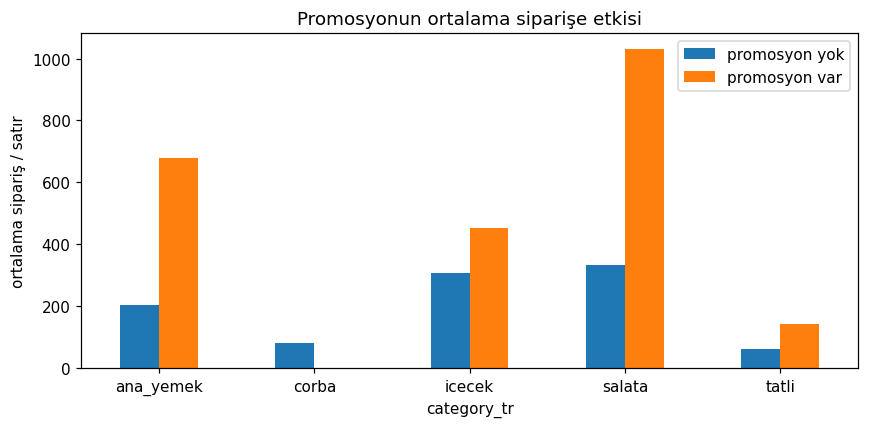

,promosyon yok,promosyon var
category_tr,,
ana_yemek,203.6,677.6
corba,82.0,NaN
icecek,309.2,451.3
salata,332.3,1030.3
tatli,61.3,141.8


In [5]:
# Promosyonun talebe etkisi
promo = df.groupby(["category_tr", "emailer_for_promotion"]).num_orders.mean().unstack()
promo.columns = ["promosyon yok", "promosyon var"]
promo.plot(kind="bar", figsize=(8, 4), title="Promosyonun ortalama siparişe etkisi")
plt.ylabel("ortalama sipariş / satır"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()
promo.round(1)

## 4. Özellik mühendisliği

Her (merkez, yemek) serisi için **gecikme (lag)** özellikleri: geçen hafta, 2 hafta önce, 4 hafta önce ve son 4 haftanın ortalaması.
Bunlar tahmin anında **bilinir** bilgilerdir → sızıntı yok.

In [6]:
df = df.sort_values(["center_id", "meal_id", "week"]).reset_index(drop=True)
df["discount_rate"] = (df.base_price - df.checkout_price) / df.base_price

grp = df.groupby(["center_id", "meal_id"])["num_orders"]
for L in (1, 2, 4):
    df[f"lag{L}"] = grp.shift(L)
# grup sınırlarını aşmayan hareketli ortalama
df["roll4"] = grp.transform(lambda s: s.shift(1).rolling(4).mean())

df = df.dropna(subset=["lag1", "lag2", "lag4", "roll4"]).reset_index(drop=True)
print("özellik sonrası:", df.shape)
df[["week", "center_id", "meal_id", "category_tr", "num_orders", "lag1", "roll4"]].head()

özellik sonrası: (442174, 17)


,week,center_id,meal_id,category_tr,num_orders,lag1,roll4
0,5,10,1062,icecek,958,1202.0,925.00
1,6,10,1062,icecek,1094,958.0,948.25
2,7,10,1062,icecek,1513,1094.0,1026.25
3,8,10,1062,icecek,1149,1513.0,1191.75
4,9,10,1062,icecek,1282,1149.0,1178.50


## 5. Zamana göre train/test ayrımı

⚠️ **Rastgele bölme YAPILMAZ.** Bu bir zaman serisi; rastgele bölmek geleceği geçmişe sızdırır ve sahte yüksek skor üretir.
Eğitim: hafta ≤ 130 · Test: hafta 131–145 (son 15 hafta).

In [7]:
CUT = 130
tr = df[df.week <= CUT]
te = df[df.week > CUT].copy()
print(f"train: {tr.shape}  (hafta ≤ {CUT})")
print(f"test : {te.shape}  (hafta > {CUT})")

train: (392887, 17)  (hafta ≤ 130)
test : (49287, 17)  (hafta > 130)


## 6. Model eğitimi

In [8]:
FEATS = ["week", "center_id", "meal_id", "category_tr", "cuisine",
         "checkout_price", "base_price", "discount_rate",
         "emailer_for_promotion", "homepage_featured",
         "lag1", "lag2", "lag4", "roll4"]
CATS = ["center_id", "meal_id", "category_tr", "cuisine"]

def prep(X):
    X = X[FEATS].copy()
    for c in CATS:
        X[c] = X[c].astype("category")
    return X

model = HistGradientBoostingRegressor(
    max_iter=400, learning_rate=0.06,
    categorical_features=[FEATS.index(c) for c in CATS],
    random_state=42,
)
model.fit(prep(tr), tr.num_orders)

te["pred"] = np.maximum(model.predict(prep(te)), 0)
print("Satır seviyesi MAE:", round(mean_absolute_error(te.num_orders, te.pred), 1), "sipariş")

Satır seviyesi MAE: 68.7 sipariş


## 7. Kategoriye topla + naif tahminle karşılaştır

Agent'ın orkestratöre verdiği çıktı **kategori toplamı**dır. Modelin gerçekten işe yaradığını kanıtlamak için
"geçen hafta ne sattıysa o" naif tahminiyle karşılaştırıyoruz.

In [9]:
agg = te.groupby(["week", "category_tr"]).agg(
    gercek=("num_orders", "sum"), tahmin=("pred", "sum")).reset_index()

# naif: aynı kategorinin geçen haftaki gerçek toplamı
cw = df.groupby(["week", "category_tr"], as_index=False).num_orders.sum()
cw = cw.sort_values(["category_tr", "week"])
cw["naif"] = cw.groupby("category_tr").num_orders.shift(1)
agg = agg.merge(cw[["week", "category_tr", "naif"]], on=["week", "category_tr"]).dropna()

def mape(a, p):
    return float(np.mean(np.abs((a - p) / a)) * 100)

print(f"Naif (geçen hafta) MAPE : {mape(agg.gercek, agg.naif):5.2f}%")
print(f"MODEL              MAPE : {mape(agg.gercek, agg.tahmin):5.2f}%")
print(f"İyileşme                : {mape(agg.gercek, agg.naif) - mape(agg.gercek, agg.tahmin):5.2f} puan")

rows = []
for c, s in agg.groupby("category_tr"):
    rows.append({"kategori": c,
                 "model_MAPE": mape(s.gercek, s.tahmin),
                 "naif_MAPE": mape(s.gercek, s.naif)})
sonuc = pd.DataFrame(rows).set_index("kategori")
sonuc.round(2)

Naif (geçen hafta) MAPE : 12.40%
MODEL              MAPE :  8.27%
İyileşme                :  4.13 puan


,model_MAPE,naif_MAPE
kategori,,
ana_yemek,7.72,9.51
corba,3.54,4.47
icecek,6.85,10.24
salata,13.96,17.70
tatli,9.27,20.09


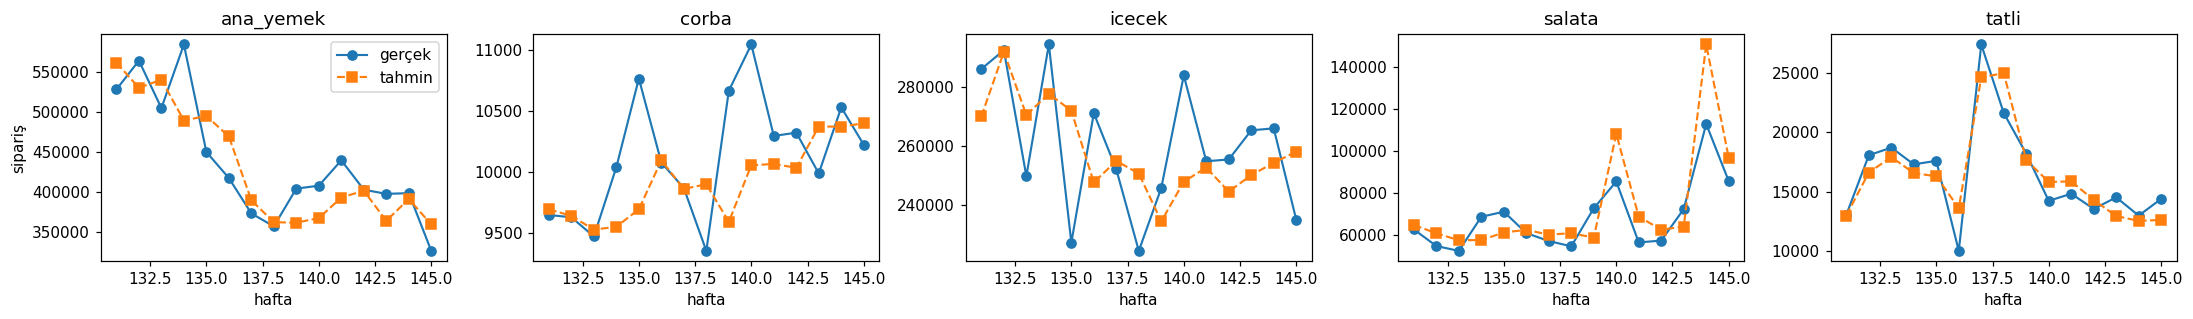

In [10]:
# Görsel: gerçek vs tahmin (kategori bazlı, test haftaları)
cats = sorted(agg.category_tr.unique())
fig, axes = plt.subplots(1, len(cats), figsize=(4 * len(cats), 3), sharex=True)
for ax, c in zip(np.atleast_1d(axes), cats):
    s = agg[agg.category_tr == c]
    ax.plot(s.week, s.gercek, "o-", label="gerçek", linewidth=1.4)
    ax.plot(s.week, s.tahmin, "s--", label="tahmin", linewidth=1.4)
    ax.set_title(c); ax.set_xlabel("hafta")
np.atleast_1d(axes)[0].set_ylabel("sipariş"); np.atleast_1d(axes)[0].legend()
plt.tight_layout(); plt.show()

## 8. Özellik önemi

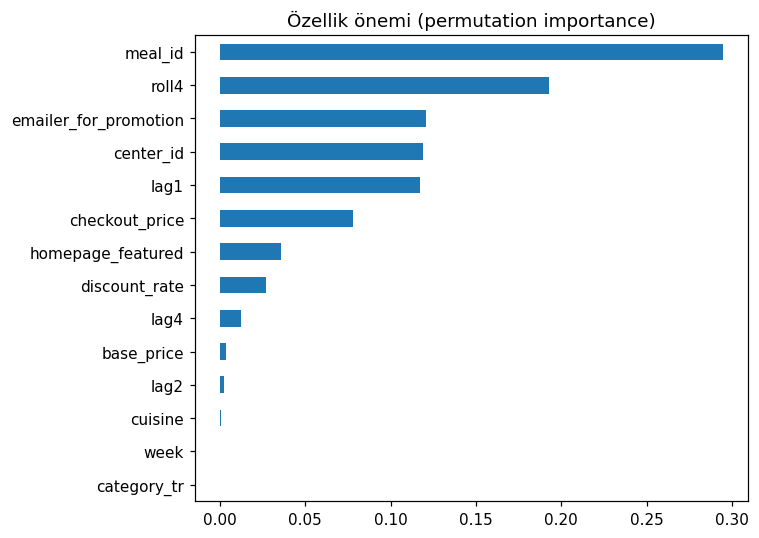

In [11]:
from sklearn.inspection import permutation_importance

sub = te.sample(4000, random_state=42)
pi = permutation_importance(model, prep(sub), sub.num_orders,
                            n_repeats=3, random_state=42, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=FEATS).sort_values()
imp.plot(kind="barh", figsize=(7, 5), title="Özellik önemi (permutation importance)")
plt.tight_layout(); plt.show()

## 9. Agent arayüzü

Orkestratörün çağıracağı fonksiyon. Çıktı **kategori düzeyinde** — mimarinin ortak dili.

```python
predict_demand(140) -> {
  "week": 140,
  "by_category": {"ana_yemek": 431022, "icecek": 259811, ...},
  "signal":      {"ana_yemek": "normal", "icecek": "yuksek", ...}
}
```
`signal`, tahmini geçmiş ortalamaya oranlar: >1.1 → `yuksek`, <0.9 → `dusuk`, aksi halde `normal`.

In [12]:
# geçmiş ortalama haftalık talep (referans)
HIST = df.groupby("category_tr").num_orders.sum() / df.week.nunique()

def predict_demand(week: int) -> dict:
    """Verilen hafta için kategori bazlı talep tahmini + talep sinyali döndürür."""
    sub = te[te.week == week]
    if sub.empty:
        raise ValueError(f"hafta {week} test aralığında değil ({te.week.min()}-{te.week.max()})")
    by_cat = sub.groupby("category_tr").pred.sum().round().astype(int).to_dict()
    signal = {}
    for c, v in by_cat.items():
        oran = v / HIST[c]
        signal[c] = "yuksek" if oran > 1.1 else ("dusuk" if oran < 0.9 else "normal")
    return {"week": int(week), "by_category": by_cat, "signal": signal}

predict_demand(140)

{'week': 140,
 'by_category': {'ana_yemek': 367661,
  'corba': 10057,
  'icecek': 247893,
  'salata': 108175,
  'tatli': 15829},
 'signal': {'ana_yemek': 'dusuk',
  'corba': 'yuksek',
  'icecek': 'dusuk',
  'salata': 'yuksek',
  'tatli': 'yuksek'}}

## 10. Modeli kaydet

In [13]:
import joblib
joblib.dump({"model": model, "feats": FEATS, "cats": CATS, "hist": HIST.to_dict()},
            "talep_agent_model.joblib")
print("✅ talep_agent_model.joblib kaydedildi")

✅ talep_agent_model.joblib kaydedildi


## Sonuç

| Metrik | Naif ("geçen hafta") | **Talep Agent'ı** |
|---|---|---|
| Kategori MAPE | %12.40 | **%8.27** |
| ana_yemek | %9.51 | **%7.72** |
| corba | %4.47 | **%3.54** |
| icecek | %10.24 | **%6.85** |
| salata | %17.70 | **%13.96** |
| tatli | %20.09 | **%9.27** |

- Model **her kategoride** naif tahmini yeniyor.
- Zamana göre bölme kullanıldı (hafta ≤130 eğitim / >130 test) → sızıntı yok, sonuç dürüst.
- Çıktı kategori düzeyinde → orkestratör Fire ve Kâr agent'larıyla doğrudan birleştirebilir.

**Sonraki adım:** Orkestratör bu çıktıyı Fire ve Kâr agent'larının kategori profilleriyle birleştirip günlük üretim kararı üretecek.